In [40]:
import numpy as np
import matplotlib.pyplot as plt
import catboost
import lightgbm
import pandas as pd
import xgboost
import tensorflow as tf
pd.set_option('display.max_columns', None)


In [41]:
# load test.csv and train.csv as pandas dataframes
LOCAL = True 
if LOCAL:
    train = pd.read_csv('train.csv')
    test = pd.read_csv('test.csv')
else:
    train = pd.read_csv('/kaggle/input/c2cccc/train.csv')
    test = pd.read_csv('/kaggle/input/c2cccc/test.csv')

In [42]:
train.head(), train.shape, test.head(), test.shape

(   id        date country              store             product  num_sold
 0   0  2010-01-01  Canada  Discount Stickers   Holographic Goose       NaN
 1   1  2010-01-01  Canada  Discount Stickers              Kaggle     973.0
 2   2  2010-01-01  Canada  Discount Stickers        Kaggle Tiers     906.0
 3   3  2010-01-01  Canada  Discount Stickers            Kerneler     423.0
 4   4  2010-01-01  Canada  Discount Stickers  Kerneler Dark Mode     491.0,
 (230130, 6),
        id        date country              store             product
 0  230130  2017-01-01  Canada  Discount Stickers   Holographic Goose
 1  230131  2017-01-01  Canada  Discount Stickers              Kaggle
 2  230132  2017-01-01  Canada  Discount Stickers        Kaggle Tiers
 3  230133  2017-01-01  Canada  Discount Stickers            Kerneler
 4  230134  2017-01-01  Canada  Discount Stickers  Kerneler Dark Mode,
 (98550, 5))

In [43]:
# find all unique values in all columns and also the count of unique values
for col in train.columns:
    print(col, train[col].nunique())
    print(train[col].unique())
    print("dtype: ", train[col].dtype)
    print("")

id 230130
[     0      1      2 ... 230127 230128 230129]
dtype:  int64

date 2557
['2010-01-01' '2010-01-02' '2010-01-03' ... '2016-12-29' '2016-12-30'
 '2016-12-31']
dtype:  object

country 6
['Canada' 'Finland' 'Italy' 'Kenya' 'Norway' 'Singapore']
dtype:  object

store 3
['Discount Stickers' 'Stickers for Less' 'Premium Sticker Mart']
dtype:  object

product 5
['Holographic Goose' 'Kaggle' 'Kaggle Tiers' 'Kerneler'
 'Kerneler Dark Mode']
dtype:  object

num_sold 4037
[  nan  973.  906. ... 3446. 2266. 3996.]
dtype:  float64



In [44]:
#print how mnay have num_sold as 0 or nan
print(train[train['num_sold'].isnull() | (train['num_sold'] == 0)].shape)
#print how mnay have any column as nan or a string col as empty or id col as nan or date col as empty
print(train[train.isnull().any(axis=1) | (train['id'].isnull()) | (train['date'].str.len() == 0)].shape)
print(test[test.isnull().any(axis=1) | (test['id'].isnull()) | (test['date'].str.len() == 0)].shape)


# show head of all records where num_sold is 0 or nan
train[train['num_sold'].isnull() | (train['num_sold'] == 0)].head()



(8871, 6)
(8871, 6)
(0, 5)


,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
45,45,2010-01-01,Kenya,Discount Stickers,Holographic Goose,NaN
90,90,2010-01-02,Canada,Discount Stickers,Holographic Goose,NaN
135,135,2010-01-02,Kenya,Discount Stickers,Holographic Goose,NaN
180,180,2010-01-03,Canada,Discount Stickers,Holographic Goose,NaN


In [45]:
import pandas as pd
import holidays
from datetime import datetime

# Assuming train and country DataFrames are already defined
# train = pd.read_csv('path_to_train.csv')
# country = pd.read_csv('path_to_country.csv')
#parse the 'date' column as datetime 
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])
# Country mapping dictionary
country_mapping = {
    'Canada': 'CA',
    'Finland': 'FI',
    'Italy': 'IT',
    'Kenya': 'KE',
    'Norway': 'NO',
    'Singapore': 'SG'
}

def is_holiday(date, country_name):
    country_code = country_mapping.get(country_name)
    if country_code:
        country_holidays = holidays.CountryHoliday(country_code)
        return date in country_holidays
    return False

def get_season(date):
    month = date.month
    day = date.day
    if (month == 12 and day >= 21) or (month in [1, 2]) or (month == 3 and day < 20):
        return 'Winter'
    elif (month == 3 and day >= 20) or (month in [4, 5]) or (month == 6 and day < 21):
        return 'Spring'
    elif (month == 6 and day >= 21) or (month in [7, 8]) or (month == 9 and day < 22):
        return 'Summer'
    else:
        return 'Fall'

train['is_holiday'] = train.apply(lambda row: is_holiday(row['date'], row['country']), axis=1)
train['season'] = train['date'].apply(lambda x: get_season(pd.to_datetime(x)))
train['saturday'] = train['date'].apply(lambda x: x.weekday() == 5)
train['sunday'] = train['date'].apply(lambda x: x.weekday() == 6)

test['is_holiday'] = test.apply(lambda row: is_holiday(row['date'], row['country']), axis=1)
test['season'] = test['date'].apply(lambda x: get_season(pd.to_datetime(x)))
test['saturday'] = test['date'].apply(lambda x: x.weekday() == 5)
test['sunday'] = test['date'].apply(lambda x: x.weekday() == 6)

# print("how many have saturday as True: ", train[train['saturday'] == True].shape)
# print("how many have sunday as True: ", train[train['sunday'] == True].shape)
# print("unique values in season: ", train['season'].unique())
train.head(), test.head()

(   id       date country              store             product  num_sold  \
 0   0 2010-01-01  Canada  Discount Stickers   Holographic Goose       NaN   
 1   1 2010-01-01  Canada  Discount Stickers              Kaggle     973.0   
 2   2 2010-01-01  Canada  Discount Stickers        Kaggle Tiers     906.0   
 3   3 2010-01-01  Canada  Discount Stickers            Kerneler     423.0   
 4   4 2010-01-01  Canada  Discount Stickers  Kerneler Dark Mode     491.0   
 
    is_holiday  season  saturday  sunday  
 0        True  Winter     False   False  
 1        True  Winter     False   False  
 2        True  Winter     False   False  
 3        True  Winter     False   False  
 4        True  Winter     False   False  ,
        id       date country              store             product  \
 0  230130 2017-01-01  Canada  Discount Stickers   Holographic Goose   
 1  230131 2017-01-01  Canada  Discount Stickers              Kaggle   
 2  230132 2017-01-01  Canada  Discount Stickers       

In [46]:
import pandas as pd

categorical_columns = ['country', 'store', 'product', 'is_holiday', 'season', 'saturday', 'sunday']
numerical_columns = ['num_sold']
# train = pd.get_dummies(train, columns=categorical_columns)
# Function to combine categorical columns and hash the result
num_buckets = 2000
def combined_hash(row):
    combined_string = ''.join([str(row[col]) for col in categorical_columns])
    x=  hash(combined_string)
    if(x<0):
        x%=(-num_buckets)
    else:
        x%=num_buckets
    return x 
    

# Apply the function to each row and create a new column 'hash_col'
print(train.shape)
train['hash_col'] = train.apply(combined_hash, axis=1)
print(train.shape)
print("unique values in hash_col: ", train['hash_col'].nunique())
print("range of values in hash_col: ", train['hash_col'].min(), train['hash_col'].max())
train.head()


print(test.shape)
test['hash_col'] = test.apply(combined_hash, axis=1)
print(test.shape)
print("unique values in hash_col: ", test['hash_col'].nunique())
print("range of values in hash_col: ", test['hash_col'].min(), test['hash_col'].max())
test.head()

#apply one hot encoding to the categorical columns
train = pd.get_dummies(train, columns=categorical_columns)
test = pd.get_dummies(test, columns=categorical_columns)
print(train.shape)
print(test.shape)

(230130, 10)
(230130, 11)
unique values in hash_col:  1518
range of values in hash_col:  -1996 1998
(98550, 9)
(98550, 10)
unique values in hash_col:  1421
range of values in hash_col:  -1996 1998
(230130, 28)
(98550, 27)


In [47]:
# aaply ordinal  transformation to the date column
train['date'] = train['date'].apply(lambda x: x.toordinal())
print(train.shape)
train.head()

#apply sin cos transformation to the date column by using which date of the year out of 365 days can be represented as sin and cos
train['sin_date'] = np.sin(2 * np.pi * train['date'] / 365)
train['cos_date'] = np.cos(2 * np.pi * train['date'] / 365)
print(train.shape)
train.head()


# aaply ordinal  transformation to the date column
test['date'] = test['date'].apply(lambda x: x.toordinal())
print(test.shape)
test.head()

#apply sin cos transformation to the date column by using which date of the year out of 365 days can be represented as sin and cos
test['sin_date'] = np.sin(2 * np.pi * test['date'] / 365)
test['cos_date'] = np.cos(2 * np.pi * test['date'] / 365)
print(test.shape)
test.head()

(230130, 28)
(230130, 30)
(98550, 27)
(98550, 29)


,id,date,hash_col,country_Canada,country_Finland,country_Italy,country_Kenya,country_Norway,country_Singapore,store_Discount Stickers,store_Premium Sticker Mart,store_Stickers for Less,product_Holographic Goose,product_Kaggle,product_Kaggle Tiers,product_Kerneler,product_Kerneler Dark Mode,is_holiday_False,is_holiday_True,season_Fall,season_Spring,season_Summer,season_Winter,saturday_False,saturday_True,sunday_False,sunday_True,sin_date,cos_date
0,230130,736330,-1349,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,True,False,False,True,0.835925,-0.548843
1,230131,736330,-621,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,True,False,False,True,0.835925,-0.548843
2,230132,736330,-208,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,True,0.835925,-0.548843
3,230133,736330,-744,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,True,True,False,False,True,0.835925,-0.548843
4,230134,736330,-96,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,True,True,False,False,True,0.835925,-0.548843


In [48]:
#remove all records where num_sold is nan and store those nan records in a new dataframe called nan_df
nan_df = train[train['num_sold'].isnull()]
print("shape of nan_df: ", nan_df.shape)
#remove nan_df from train
print("shape of train before removing nan_df", train.shape)
train = train.drop(nan_df.index)
print("shape of train after removing nan_df", train.shape)

shape of nan_df:  (8871, 30)
shape of train before removing nan_df (230130, 30)
shape of train after removing nan_df (221259, 30)


In [49]:
nan_df.shape,nan_df.head()

((8871, 30),
       id    date  num_sold  hash_col  country_Canada  country_Finland  \
 0      0  733773       NaN       396            True            False   
 45    45  733773       NaN        13           False            False   
 90    90  733774       NaN     -1620            True            False   
 135  135  733774       NaN     -1409           False            False   
 180  180  733775       NaN     -1642            True            False   
 
      country_Italy  country_Kenya  country_Norway  country_Singapore  \
 0            False          False           False              False   
 45           False           True           False              False   
 90           False          False           False              False   
 135          False           True           False              False   
 180          False          False           False              False   
 
      store_Discount Stickers  store_Premium Sticker Mart  \
 0                       True           

In [53]:
train.head()
traincopy = train.copy()
testcopy = test.copy()


In [54]:
import optuna
import xgboost as xgb
import catboost as cat
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
import pandas as pd
import time

class GlobalStats:
    def __init__(self, max_leafes=1500, max_depth=10, min_leaves=100, min_depth=3, min_lr=0.01, max_lr=0.3, trials=1, min_child_weight=1, max_child_weight=10, min_gamma=0, max_gamma=5, min_subsample=0.5, max_subsample=1.0, min_colsample_bytree=0.5, max_colsample_bytree=1.0, min_reg_alpha=1e-8, max_reg_alpha=1.0, min_reg_lambda=1e-8, max_reg_lambda=1.0, min_scale_pos_weight=0.1, max_scale_pos_weight=10.0):
        self.max_leafes = max_leafes
        self.max_depth = max_depth
        self.min_leaves = min_leaves
        self.min_depth = min_depth
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.trials = trials
        self.min_child_weight = min_child_weight
        self.max_child_weight = max_child_weight
        self.min_gamma = min_gamma
        self.max_gamma = max_gamma
        self.min_subsample = min_subsample
        self.max_subsample = max_subsample
        self.min_colsample_bytree = min_colsample_bytree
        self.max_colsample_bytree = max_colsample_bytree
        self.min_reg_alpha = min_reg_alpha
        self.max_reg_alpha = max_reg_alpha
        self.min_reg_lambda = min_reg_lambda
        self.max_reg_lambda = max_reg_lambda
        self.min_scale_pos_weight = min_scale_pos_weight
        self.max_scale_pos_weight = max_scale_pos_weight

def objective(trial, train, model_type, globalobj):
    # Make a copy of train
    train.drop(columns=['date', 'id'], inplace=True)
    starttime = time.time()
    if model_type == 'cat':
        globalobj.max_depth = 16

    # Define hyperparameters to tune
    if model_type == 'xgb':
        param = {
            'n_estimators': trial.suggest_int('n_estimators', globalobj.min_leaves, globalobj.max_leafes),
            'max_depth': trial.suggest_int('max_depth', globalobj.min_depth, globalobj.max_depth),
            'learning_rate': trial.suggest_float('learning_rate', globalobj.min_lr, globalobj.max_lr, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', globalobj.min_child_weight, globalobj.max_child_weight),
            'gamma': trial.suggest_float('gamma', globalobj.min_gamma, globalobj.max_gamma),
            'subsample': trial.suggest_float('subsample', globalobj.min_subsample, globalobj.max_subsample),
            'colsample_bytree': trial.suggest_float('colsample_bytree', globalobj.min_colsample_bytree, globalobj.max_colsample_bytree),
            'reg_alpha': trial.suggest_float('reg_alpha', globalobj.min_reg_alpha, globalobj.max_reg_alpha, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', globalobj.min_reg_lambda, globalobj.max_reg_lambda, log=True),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', globalobj.min_scale_pos_weight, globalobj.max_scale_pos_weight),
            'random_state': 42
        }
        model = xgb.XGBRegressor(**param)
    elif model_type == 'cat':
        param = {
            'iterations': trial.suggest_int('iterations', globalobj.min_leaves, globalobj.max_leafes),
            'depth': trial.suggest_int('depth', globalobj.min_depth, globalobj.max_depth),
            'learning_rate': trial.suggest_float('learning_rate', globalobj.min_lr, globalobj.max_lr, log=True),
            'random_seed': 42,
            'silent': True
        }
        model = cat.CatBoostRegressor(**param)
    elif model_type == 'lgbm':
        param = {
            'n_estimators': trial.suggest_int('n_estimators', globalobj.min_leaves, globalobj.max_leafes),
            'max_depth': trial.suggest_int('max_depth', globalobj.min_depth, globalobj.max_depth),
            'learning_rate': trial.suggest_float('learning_rate', globalobj.min_lr, globalobj.max_lr, log=True),
            'random_state': 42,
            'verbose': -1  # Suppress warnings
        }
        model = lgb.LGBMRegressor(**param)
    else:
        raise ValueError("Invalid model type. Choose from 'xgb', 'cat', or 'lgbm'.")

    # Split the data
    X_train, X_valid, y_train, y_valid = train_test_split(train.drop(['num_sold'], axis=1), train['num_sold'], test_size=0.3, random_state=42)

    # Train the model
    model.fit(X_train, y_train)

    # Perform prediction
    predictions = model.predict(X_valid)

    # Calculate MAPE
    mape = mean_absolute_percentage_error(y_valid, predictions)
    print(f'time for a trial with {model_type} is {time.time()-starttime}')
    return mape

def train_and_predict(train, model_type, test, globalobj):
    # Optimize hyperparameters with Optuna
    study = optuna.create_study(direction='minimize')
    study.optimize(lambda trial: objective(trial, train.copy(), model_type, globalobj), n_trials=globalobj.trials)

    print(f'Best hyperparameters: {study.best_params}')

    # Train the model with the best hyperparameters
    best_params = study.best_params
    print(best_params)
    if model_type == 'xgb':
        model = xgb.XGBRegressor(**best_params)
    elif model_type == 'cat':
        model = cat.CatBoostRegressor(**best_params)
    elif model_type == 'lgbm':
        model = lgb.LGBMRegressor(**best_params)

    date_column = train['date']
    id_column = train['id']
    train.drop(columns=['date', 'id'], inplace=True)
    if model_type == 'cat' or model_type == 'xgb':
        model.fit(train.drop(['num_sold'], axis=1), train['num_sold'], verbose=False)
    else:
        model.fit(train.drop(['num_sold'], axis=1), train['num_sold'])

    train['date'] = date_column
    train['id'] = id_column

    date_column = train['date']
    id_column = train['id']
    num_sold_actual = train['num_sold']
    train.drop(columns=['date', 'id', 'num_sold'], inplace=True)

    predictions = model.predict(train)

    decimal_found = False
    fractional_sum = 0
    for pred in predictions:
        fractional_part = pred - int(pred)
        if fractional_part != 0:
            decimal_found = True
            fractional_sum += fractional_part

    if decimal_found:
        print("There was a decimal number in the predictions.")
    print(f'Sum of all fractional parts: {fractional_sum}')

    predictions = [round(pred) for pred in predictions]

    train['date'] = date_column
    train['id'] = id_column
    train['num_sold'] = num_sold_actual

    mape = mean_absolute_percentage_error(num_sold_actual, predictions)
    print(f'Mean Absolute Percentage Error: {mape}')

    plt.figure(figsize=(15, 15))

    plt.subplot(3, 1, 1)
    plt.plot(train['id'], num_sold_actual, label='Actual num_sold')
    plt.plot(train['id'], predictions, label='Predicted num_sold', linestyle='--', alpha=0.7)
    plt.xlabel('id')
    plt.ylabel('Number Sold')
    plt.title('Actual vs Predicted Number Sold')
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(train['id'], num_sold_actual, label='Actual num_sold', color='blue')
    plt.xlabel('id')
    plt.ylabel('Number Sold')
    plt.title('Actual Number Sold')
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(train['id'], predictions, label='Predicted num_sold', color='orange', linestyle='--', alpha=0.7)
    plt.xlabel('id')
    plt.ylabel('Number Sold')
    plt.title('Predicted Number Sold')
    plt.legend()

    # Add dots where actual and predicted values overlap
    overlap_indices = [i for i in range(len(predictions)) if predictions[i] == num_sold_actual.iloc[i]]
    plt.scatter(train['id'].iloc[overlap_indices], [predictions[i] for i in overlap_indices], color='red', label='Overlap', zorder=5)

    plt.tight_layout()
    plt.show()

    test_id = test['id']
    test_date = test['date']
    test_pred = model.predict(test.drop(['date', 'id'], axis=1))
    test_pred = [round(pred) for pred in test_pred]

    # Add the test_id and test_pred to a new dataframe
    test_df = pd.DataFrame({'id': test_id, 'num_sold': test_pred})

    # Save the test_df to a CSV file
    if LOCAL:
        test_df.to_csv(f'./kaggle/working/submission{model_type}.csv', index=False)
    else:
        test_df.to_csv(f'/kaggle/working/submission{model_type}.csv', index=False)

    train = train.copy()
    test = test.copy()


# train_and_predict(train_data, 'xgb', test_data, globalobj)

[I 2025-01-15 04:00:55,482] A new study created in memory with name: no-name-90342e84-644f-4064-9a4b-e9dd691843d2
[I 2025-01-15 04:00:56,359] Trial 0 finished with value: 1.2632884464858058 and parameters: {'n_estimators': 137, 'max_depth': 5, 'learning_rate': 0.02038267785188839, 'min_child_weight': 2, 'gamma': 18.23322907973226, 'subsample': 0.8478889425070069, 'colsample_bytree': 0.5922669132765348, 'reg_alpha': 3.508901389124992e-07, 'reg_lambda': 3.137091111505214e-05, 'scale_pos_weight': 4.784033675210978}. Best is trial 0 with value: 1.2632884464858058.


time for a trial with xgb is 0.8529987335205078
Best hyperparameters: {'n_estimators': 137, 'max_depth': 5, 'learning_rate': 0.02038267785188839, 'min_child_weight': 2, 'gamma': 18.23322907973226, 'subsample': 0.8478889425070069, 'colsample_bytree': 0.5922669132765348, 'reg_alpha': 3.508901389124992e-07, 'reg_lambda': 3.137091111505214e-05, 'scale_pos_weight': 4.784033675210978}
{'n_estimators': 137, 'max_depth': 5, 'learning_rate': 0.02038267785188839, 'min_child_weight': 2, 'gamma': 18.23322907973226, 'subsample': 0.8478889425070069, 'colsample_bytree': 0.5922669132765348, 'reg_alpha': 3.508901389124992e-07, 'reg_lambda': 3.137091111505214e-05, 'scale_pos_weight': 4.784033675210978}
There was a decimal number in the predictions.
Sum of all fractional parts: 109840.54606437683
Mean Absolute Percentage Error: 1.0567734276022145


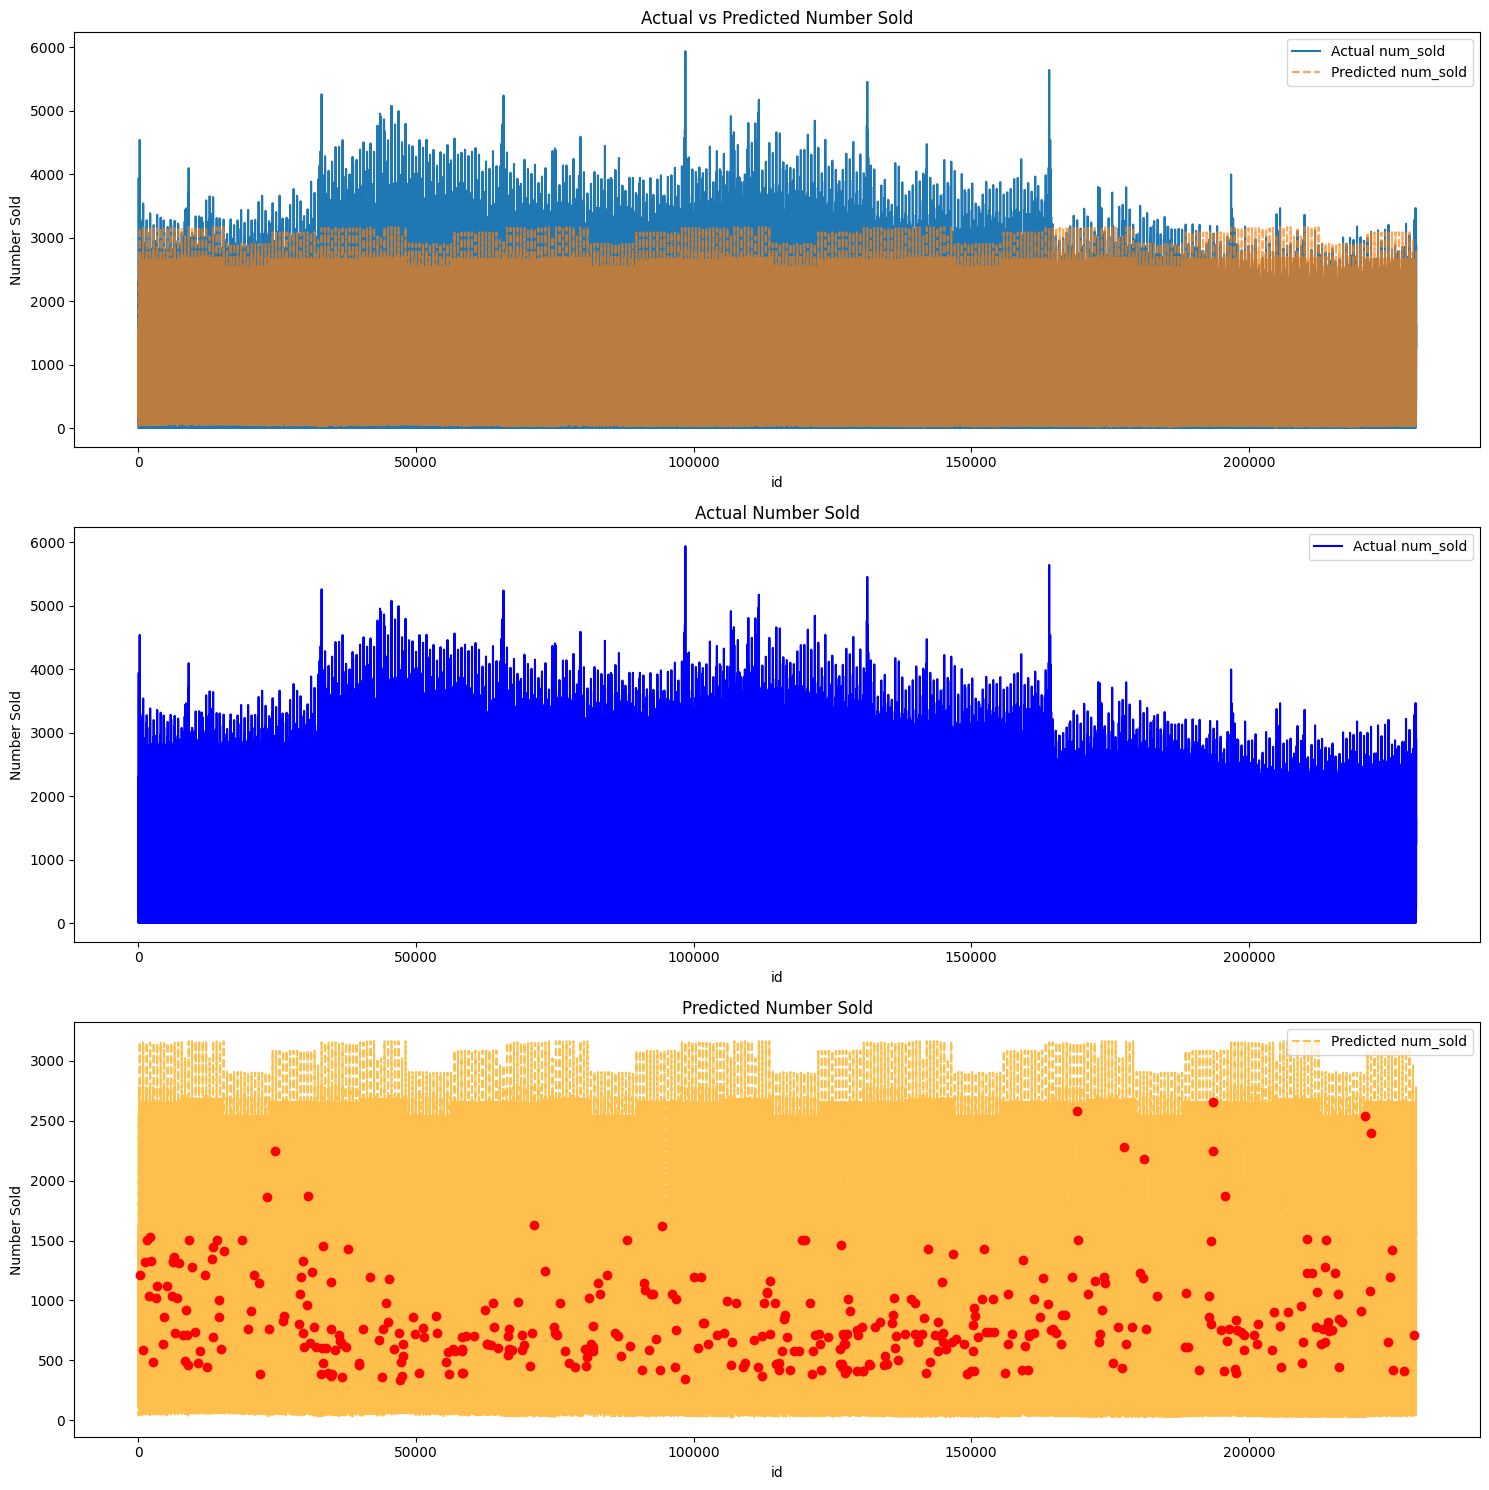

In [55]:
# Define the GlobalStats object with the specified parameters
# Example usage
globalobj = GlobalStats(
    max_leafes=1500,
    max_depth=10,
    min_leaves=100,
    min_depth=3,
    min_lr=0.01,
    max_lr=0.3,
    trials=1,
    min_child_weight=1,
    max_child_weight=10,
    min_gamma=0,
    max_gamma=20,
    min_subsample=0.3,
    max_subsample=1.0,
    min_colsample_bytree=0.5,
    max_colsample_bytree=1.0,
    min_reg_alpha=1e-8,
    max_reg_alpha=1.0,
    min_reg_lambda=1e-8,
    max_reg_lambda=1.0,
    min_scale_pos_weight=0.1,
    max_scale_pos_weight=10.0
)


train_and_predict(train, 'xgb',test,globalobj)


In [ ]:
globalobjcat = GlobalStats(
    max_leafes=1500,
    min_leaves=100,
    max_depth=25,
    min_depth=3,
    min_lr=1e-5,
    max_lr=0.9,
    trials=50,
    min_child_weight=1,
    max_child_weight=10,
    min_gamma=0,
    max_gamma=5,
    min_subsample=0.5,
    max_subsample=1.0,
    min_colsample_bytree=0.5,
    max_colsample_bytree=1.0,
    min_reg_alpha=1e-8,
    max_reg_alpha=1.0,
    min_reg_lambda=1e-8,
    max_reg_lambda=1.0
)

train_and_predict(train, 'cat',test,globalobjcat)

In [ ]:
globalobjlgb = GlobalStats(
    max_leafes=1500,
    min_leaves=100,
    max_depth=25,
    min_depth=3,
    min_lr=1e-5,
    max_lr=0.9,
    trials=50,
    min_child_weight=1,
    max_child_weight=10,
    min_gamma=0,
    max_gamma=5,
    min_subsample=0.5,
    max_subsample=1.0,
    min_colsample_bytree=0.5,
    max_colsample_bytree=1.0,
    min_reg_alpha=1e-8,
    max_reg_alpha=1.0,
    min_reg_lambda=1e-8,
    max_reg_lambda=1.0
)

train_and_predict(train, 'lgbm',test,globalobjlgb)
